In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Task 1

In [13]:

Grc_df = pd.read_csv("Grocery_dataset.csv")

rows, columns = Grc_df.shape
print(f"There are {rows} rows and {columns} columns.\n")

print("The first 10 rows:")
print(Grc_df.head(10))
print()
print("The last 10 rows:")
print(Grc_df.tail(10))

There are 5000 rows and 12 columns.

The first 10 rows:
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15        9.300          Low Fat         0.016047   
1           DRC01        5.920          Regular         0.019278   
2           FDN15       17.500          Low Fat         0.016760   
3           FDX07       19.200          Regular         0.000000   
4           NCD19        8.930          Low Fat         0.000000   
5           FDP36       10.395          Regular         0.000000   
6           FDO10       13.650          Regular         0.012741   
7           FDP10          NaN          Low Fat         0.127470   
8           FDH17       16.200          Regular         0.016687   
9           FDU28       19.200          Regular         0.094450   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  1

Task 2

In [14]:
print(Grc_df.isnull().sum()) # Checks if it is null values and prints it out.
Grc_df.dropna(inplace=True) # Removes the rows with missing values.
print(Grc_df.shape) # Shows the remaining rows and columns.
Grc_df.reset_index(drop=True, inplace=True) # Cleans up the index after removal
print(Grc_df.isnull().sum()) # Confirms no missing values remain.

Item_Identifier                 0
Item_Weight                   818
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1439
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64
(2743, 12)
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


Task 3

In [15]:
print(f"{Grc_df["Outlet_Size"].unique()}\n")
print(f"There are {Grc_df["Outlet_Size"].nunique()} unique rows\n")
print("Small is the minimum size and High is the maximum size")

<StringArray>
['Medium', 'High', 'Small']
Length: 3, dtype: str

There are 3 unique rows

Small is the minimum size and High is the maximum size


Task 4

In [16]:
print(Grc_df["Item_Fat_Content"].unique()) # Shows all unique values in Item_Fat coloumn.
print(Grc_df["Item_Fat_Content"].nunique()) # Counts all unique values


# Fixes inconsistent writing methods.
Grc_df['Item_Fat_Content'] = Grc_df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

# Confirms that it is fixed
print(Grc_df['Item_Fat_Content'].unique())
print(Grc_df['Item_Fat_Content'].nunique())

<StringArray>
['Low Fat', 'Regular', 'low fat', 'reg', 'LF']
Length: 5, dtype: str
5
<StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
2


Task 5

In [17]:
Grc_new_df = Grc_df.drop(Grc_df.columns[[0,6]], axis='columns')
print(Grc_new_df.head)

<bound method NDFrame.head of       Item_Weight Item_Fat_Content  Item_Visibility              Item_Type  \
0           9.300          Low Fat         0.016047                  Dairy   
1           5.920          Regular         0.019278            Soft Drinks   
2          17.500          Low Fat         0.016760                   Meat   
3           8.930          Low Fat         0.000000              Household   
4          10.395          Regular         0.000000           Baking Goods   
...           ...              ...              ...                    ...   
2738       18.750          Low Fat         0.010382              Household   
2739        8.520          Low Fat         0.027059            Soft Drinks   
2740       15.500          Regular         0.126200  Fruits and Vegetables   
2741       16.700          Regular         0.119462  Fruits and Vegetables   
2742        9.600          Regular         0.027455            Snack Foods   

      Item_MRP  Outlet_Establishm

Task 6

In [18]:
outletTypes = Grc_new_df['Outlet_Type'].unique()
print(outletTypes)
SupType_1 = Grc_new_df[Grc_new_df['Outlet_Type'] == outletTypes[0]].copy()
SupType_2 = Grc_new_df[Grc_new_df['Outlet_Type'] == outletTypes[1]].copy()
print(SupType_1)
print(SupType_2)

<StringArray>
['Supermarket Type1', 'Supermarket Type2']
Length: 2, dtype: str
      Item_Weight Item_Fat_Content  Item_Visibility              Item_Type  \
0            9.30          Low Fat         0.016047                  Dairy   
2           17.50          Low Fat         0.016760                   Meat   
3            8.93          Low Fat         0.000000              Household   
5           13.65          Regular         0.012741            Snack Foods   
6           11.80          Low Fat         0.000000  Fruits and Vegetables   
...           ...              ...              ...                    ...   
2735        17.60          Low Fat         0.018905     Health and Hygiene   
2737         5.98          Low Fat         0.075675            Hard Drinks   
2738        18.75          Low Fat         0.010382              Household   
2739         8.52          Low Fat         0.027059            Soft Drinks   
2741        16.70          Regular         0.119462  Fruits and

Task 7

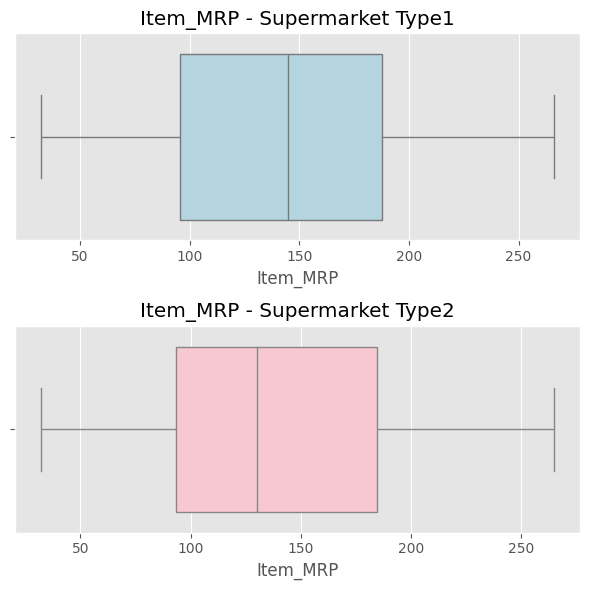

Median MRP - Type1: 144.6102
Median MRP - Type2: 130.18099999999998


In [19]:
plt.style.use('ggplot')

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

sns.boxplot(x=SupType_1['Item_MRP'], ax=axes[0], color='lightblue')
axes[0].set_title('Item_MRP - Supermarket Type1')

sns.boxplot(x=SupType_2['Item_MRP'], ax=axes[1], color='pink')
axes[1].set_title('Item_MRP - Supermarket Type2')

plt.tight_layout()
plt.show()

print("Median MRP - Type1:", SupType_1['Item_MRP'].median())
print("Median MRP - Type2:", SupType_2['Item_MRP'].median())

Task 8

In [20]:
# Combines SupType_1 and SupType_2
Grc_Concat_df = pd.concat([SupType_1, SupType_2])

# Sort the values based in Item_Outlet_Sales in ascending order. From lowest to highest.
Grc_Concat_df = Grc_Concat_df.sort_values(by='Item_Outlet_Sales')

# Shows the store with the lowest sales.head(1) chooses the first row from the sort.
print(Grc_Concat_df[['Item_Outlet_Sales', 'Outlet_Location_Type']].head(1))

      Item_Outlet_Sales Outlet_Location_Type
1277             73.238               Tier 3


The store with the lowest sales (Item_Outlet_Sales = 73.238) has Outlet_Location_Type = Tier 3

Task 9

In [ ]:
# Creates a Multindex based on Outlet_Size and Outlet_Location_Type-
Grc_Concat_df = Grc_Concat_df.set_index(['Outlet_Size', 'Outlet_Location_Type'])

# Show the results.
Grc_Concat_df.head()

Task 10